<a href="https://colab.research.google.com/github/aryakamat01-sketch/pbs-generic-erosion/blob/main/pbs_generic_erosion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
print(pd.__version__)

2.2.3


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data

PBS and RPBS Date of Supply supplementary reports, July 2022 – June 2026
(48 months). Source: Australian Government Department of Health, Disability
and Ageing, www.pbs.gov.au

These supplementary reports include dispensing pharmacy type but exclude
Section 100 special arrangements, so this analysis covers general community
supply only.

In [3]:
import glob

files = sorted(glob.glob('/content/drive/MyDrive/pbs-data/dos-*.csv'))
print(files)

frames = [pd.read_csv(f) for f in files]
raw = pd.concat(frames, ignore_index=True)
print(raw.shape)

['/content/drive/MyDrive/pbs-data/dos-jul-2022-to-jun-2023-phrmcy-type.csv', '/content/drive/MyDrive/pbs-data/dos-jul-2023-to-jun-2024-phrmcy-type.csv', '/content/drive/MyDrive/pbs-data/dos-jul-2024-to-jun-2025-phrmcy-type.csv', '/content/drive/MyDrive/pbs-data/dos-jul-2025-to-jun-2026-phrmcy-type.csv']
(1490524, 12)


## Joining drug names

The supplementary reports contain ITEM_CODE but no drug name, so the PBS
item-to-drug mapping file is required. The file is not UTF-8 encoded and
needs Latin-1.

192 of 789,577 rows found no matching drug name (0.02%) — most likely
historical item codes or the 99999Z placeholder used for unlisted RPBS items.
Left as-is rather than dropped.

In [4]:
drug_map = pd.read_csv('/content/drive/MyDrive/pbs-data/pbs-item-drug-map.csv', encoding='latin-1')
print(drug_map.shape)
drug_map.head()

(12162, 4)


,ITEM_CODE,DRUG_NAME,FORM/STRENGTH,ATC5_Code
0,00000A,MISSING ITEM CODE,Missing Item Code,Z
1,00013Q,EXTEMPORANEOUSLY PREPARED,Creams,Z
2,00015T,EXTEMPORANEOUSLY PREPARED,Ear drops,Z
3,00016W,ELIXIRS,Generic term,Z
4,00019B,EXTEMPORANEOUSLY PREPARED,Eye drops containing cocaine hcl,Z


## Scope decisions

**Above co-payment only.** Under co-payment scripts record a zero government
contribution, so total cost is zero and cost per script would compute as $0.
Including them would fabricate price collapses that never happened.
This excludes roughly 16% of rows.

**S90 community pharmacies only.** Excludes public and private hospital
dispensing (S94) and approved medical practitioners (S92), where pricing
arrangements differ. Retail generic competition is the question here, so
community pharmacy is the right population.

In [5]:
work = raw[(raw['SCRIPT_TYPE'] == 'ABOVE CO-PAYMENT') & (raw['PHRMCY_TYPE'] == 'S90')].copy()
work = work.merge(drug_map, on='ITEM_CODE', how='left')

print(work.shape)
print(work['DRUG_NAME'].isna().sum())

(789577, 15)
192


## Key metric: cost per script

cost_per_script = TOTAL_COST / PRESCRIPTIONS

**Important limitation.** TOTAL_COST includes the ex-manufacturer price plus
wholesale and retail mark-up, the dispensing fee and other fees. The
dispensing fee is roughly fixed per script, which puts a floor under cost per
script — the observed minimum across the dataset is $6.19.

This means measured price erosion systematically **understates** true
manufacturer price erosion, and the understatement is worst for the cheapest
drugs. A generic whose manufacturer price falls 90% may show far less
erosion here.

TOTAL_COST also excludes brand premiums paid by patients, so any premium
an originator charges after generic entry is invisible in this data.

In [6]:
work['date'] = pd.to_datetime(work['MONTH_OF_SUPPLY'], format='%Y%m')
work['cost_per_script'] = work['TOTAL_COST'] / work['PRESCRIPTIONS']

print(work['date'].min(), work['date'].max())
print(work['date'].nunique())
print(work['cost_per_script'].describe())

2022-07-01 00:00:00 2026-06-01 00:00:00
48
count    789577.000000
mean        569.329926
std        1939.327600
min           6.190000
25%          22.560000
50%          45.680000
75%         225.980000
max      201042.960000
Name: cost_per_script, dtype: float64


## Completeness check

The Explanatory Notes warn that recent months are less complete and that the
report "should not be used to analyse the recent trends". Checking total
prescriptions for the final six months: values range 17.3M–20.0M with the
last month among the highest, showing no sign of truncation. All 48 months
retained.

In [7]:
work.groupby('date')['PRESCRIPTIONS'].sum().tail(6)

,PRESCRIPTIONS
date,
2026-01-01,17255493
2026-02-01,17553355
2026-03-01,19947341
2026-04-01,18935944
2026-05-01,19676963
2026-06-01,19992133


## Aggregating to item level

Collapsing patient categories to give one row per item code per month.

Working at ITEM_CODE rather than DRUG_NAME is deliberate: a single drug
name covers multiple strengths and pack sizes at genuinely different
prices, so aggregating by name would let shifts in the product mix appear
as price movement. Item code is the level at which PBS pricing actually
operates, so a change there is a real price change.

In [8]:
monthly = (work.groupby(['ITEM_CODE', 'date'])
               .agg(scripts=('PRESCRIPTIONS', 'sum'),
                    cost=('TOTAL_COST', 'sum'))
               .reset_index())

monthly['cost_per_script'] = monthly['cost'] / monthly['scripts']

labels = drug_map[['ITEM_CODE', 'DRUG_NAME', 'FORM/STRENGTH']]
monthly = monthly.merge(labels, on='ITEM_CODE', how='left')

print(monthly.shape)
monthly.head()

(195389, 7)


,ITEM_CODE,date,scripts,cost,cost_per_script,DRUG_NAME,FORM/STRENGTH
0,00000B,2022-07-01,1747,79710.93,45.627321,NaN,NaN
1,00000B,2022-08-01,1910,117560.95,61.550236,NaN,NaN
2,00000B,2022-09-01,1730,86583.38,50.048197,NaN,NaN
3,00000B,2022-10-01,1714,97024.92,56.607305,NaN,NaN
4,00000B,2022-11-01,1721,119127.70,69.220046,NaN,NaN


## Selecting candidates

Two filters:

**Present in all 48 months.** Before-and-after comparison is impossible for
an item that appeared or disappeared partway through the window.

**More than 100,000 total prescriptions.** The median row in the raw data
has only 31 prescriptions, and low-volume items produce unstable monthly
price estimates. This threshold keeps the analysis to items where cost per
script is a reliable measure.

This leaves 885 candidates from 5,479 items.

In [9]:
totals = (monthly.groupby('ITEM_CODE')
                 .agg(total_scripts=('scripts', 'sum'),
                      months=('date', 'nunique'))
                 .reset_index())

print(len(totals))
print((totals['months'] == 48).sum())

candidates = totals[(totals['months'] == 48) & (totals['total_scripts'] > 100000)]
print(len(candidates))

5479
2706
885


In [10]:
cand = monthly[monthly['ITEM_CODE'].isin(candidates['ITEM_CODE'])].copy()
cand = cand.sort_values(['ITEM_CODE', 'date'])

first6 = cand.groupby('ITEM_CODE').head(6).groupby('ITEM_CODE')['cost_per_script'].mean()
last6  = cand.groupby('ITEM_CODE').tail(6).groupby('ITEM_CODE')['cost_per_script'].mean()

change = pd.DataFrame({'start_price': first6, 'end_price': last6}).reset_index()
change['pct_change'] = (change['end_price'] - change['start_price']) / change['start_price'] * 100

change = change.merge(labels, on='ITEM_CODE', how='left')
change = change.merge(candidates[['ITEM_CODE', 'total_scripts']], on='ITEM_CODE')

change.sort_values('pct_change').head(20)

,ITEM_CODE,start_price,end_price,pct_change,DRUG_NAME,FORM/STRENGTH,total_scripts
786,11178H,7774.626147,1569.786520,-79.808849,USTEKINUMAB,Injection 45 mg in 0.5 mL,159190
851,12152N,1142.484535,444.794342,-61.067802,AFLIBERCEPT,Solution for intravitreal injection 3.6 mg in ...,265533
852,12153P,1284.982918,501.336102,-60.984999,AFLIBERCEPT,Solution for intravitreal injection 3.6 mg in ...,115318
313,05262Y,2026.686256,794.078229,-60.818887,FINGOLIMOD,Capsule 500 micrograms (as hydrochloride),140767
109,01952R,74.205607,29.428808,-60.341531,RASAGILINE,Tablet 1 mg (as mesilate),320508
688,10104T,293.443592,124.065189,-57.720941,FERRIC CARBOXYMALTOSE,Injection 500 mg (iron) in 10 mL,1210719
825,11702X,298.910069,127.078392,-57.486078,FERRIC CARBOXYMALTOSE,Injection 1000 mg (iron) in 20 mL,618175
729,10529E,107.574709,49.961565,-53.556402,LURASIDONE,Tablet containing lurasidone hydrochloride 80 mg,216858
722,10486X,98.802262,46.052259,-53.389469,LISDEXAMFETAMINE,Capsule containing lisdexamfetamine dimesilate...,1683375
723,10492F,98.765812,46.042734,-53.381911,LISDEXAMFETAMINE,Capsule containing lisdexamfetamine dimesilate...,1049230


## Two different patterns

Ranking candidates by four-year price change and plotting the largest
fallers reveals two distinct shapes that the summary table cannot
distinguish:

**Step changes.** Lisdexamfetamine, sacubitril + valsartan and ustekinumab
hold a flat price for years, then drop once and stay down. Lisdexamfetamine
falls from roughly \$100 to \$46 in a single month; ustekinumab from about
\$7,800 to \$1,570 in mid-2025.

**Staircases.** Rasagiline and fingolimod decline through four or five
smaller steps spread across the whole window. Total decline is comparable,
but it arrives incrementally.

**Both are regulated price changes.** Under the PBS, prices are set by
government, so neither pattern is a market price moving freely. What
differs is the trigger. A step change is consistent with first generic
entry, which prompts a single large statutory reduction. A staircase is
consistent with successive price-disclosure cycles, where accumulated
market discounting is periodically fed back into the listed price. The
underlying force is competition in both cases — the difference is whether
it arrives at once or is absorbed gradually.

Verification: the lisdexamfetamine reduction took effect 1 December 2025,
matching the observed drop, and generic lisdexamfetamine is now registered
for supply in Australia. The change applied across all strengths, which
explains why six separate item codes fall between 53.3% and 53.4% — a
single pricing event affecting every presentation of the molecule
simultaneously.

Magnitude alone cannot separate the two patterns; the shape of the decline
is what distinguishes them. The next step is to classify all 885 candidates
on that basis.

Note that ustekinumab and aflibercept are biologics — their competitors are
biosimilars rather than small-molecule generics.

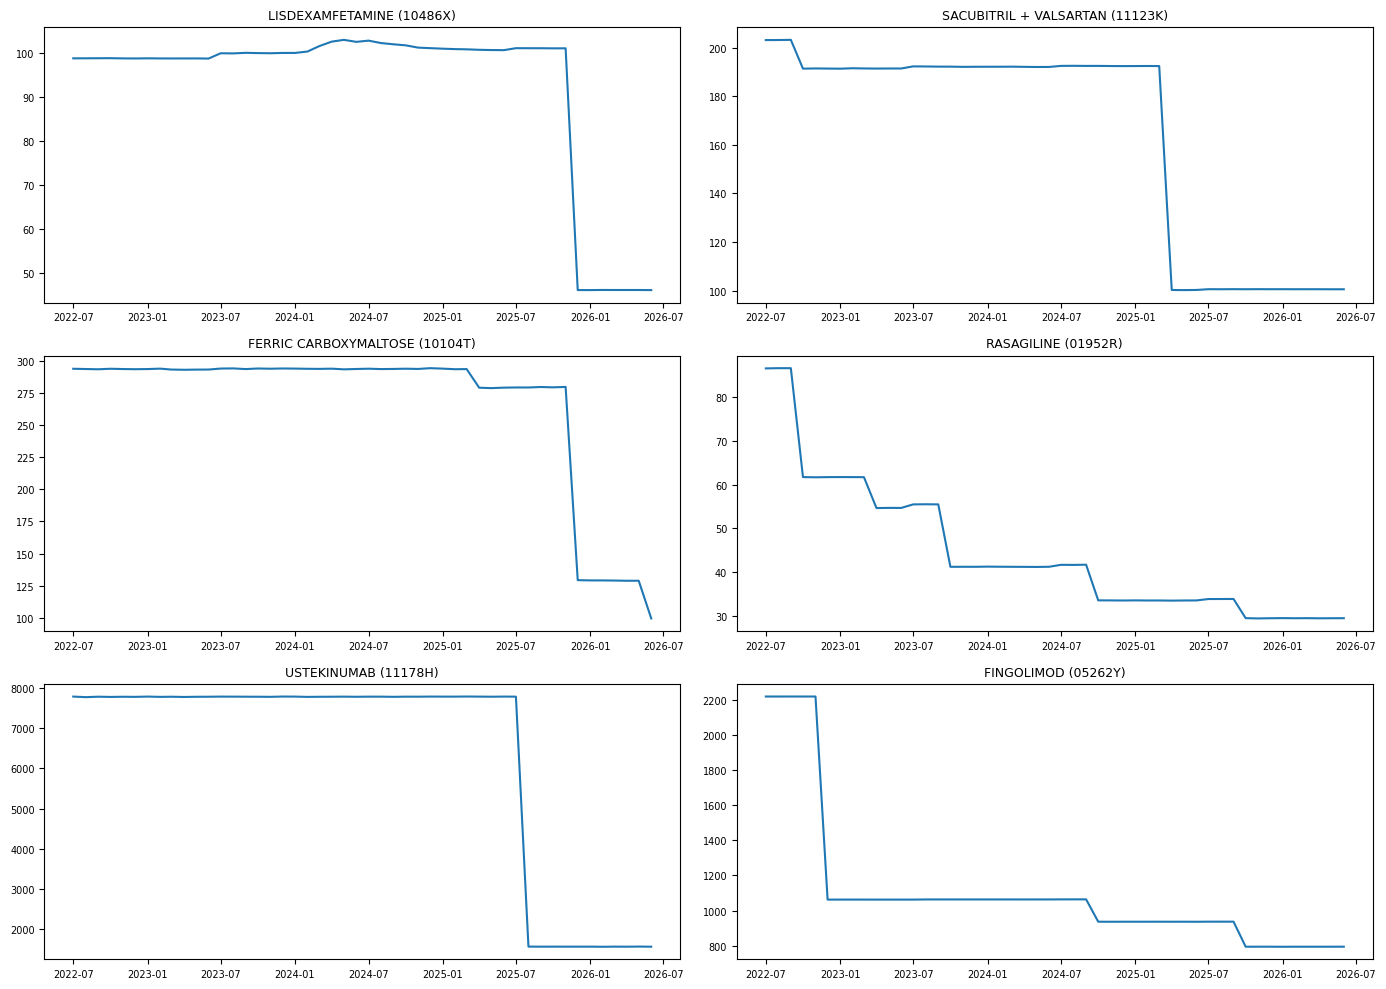

In [11]:
import matplotlib.pyplot as plt

picks = ['10486X', '11123K', '10104T', '01952R', '11178H', '05262Y']

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, code in zip(axes.flat, picks):
    d = monthly[monthly['ITEM_CODE'] == code].sort_values('date')
    ax.plot(d['date'], d['cost_per_script'])
    ax.set_title(f"{d['DRUG_NAME'].iloc[0]} ({code})", fontsize=9)
    ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

## Classifying the shape of each decline

To separate the two patterns automatically rather than by eye, each item's
largest single-month drop is compared against its total four-year change:

`share_of_decline = largest monthly drop / total change`

A value near 1.0 means one month accounts for almost the entire decline —
a step change. A low value means the fall was spread across many months —
a staircase.

Restricting to items that fell more than 20% over the window gives 82
candidates. Across these, the median share_of_decline is 0.86: for a
typical faller, a single month accounts for 86% of the whole four-year
decline. Step changes are the dominant pattern, not one of two equal halves.

Counting drops of 5% or more supports this — 29 items had exactly one,
16 had two, 26 had three, and only 11 had four or more.

A small number of items show share_of_decline above 1.0, meaning the largest
single-month drop exceeded the net four-year change. This implies a partial
price recovery after the drop, and is flagged for follow-up.

In [12]:
cand = cand.sort_values(['ITEM_CODE', 'date'])
cand['mom'] = cand.groupby('ITEM_CODE')['cost_per_script'].pct_change() * 100

diag = (cand.groupby('ITEM_CODE')
            .agg(max_drop=('mom', 'min'),
                 n_drops_5pct=('mom', lambda s: (s <= -5).sum()))
            .reset_index())

diag = diag.merge(change, on='ITEM_CODE')
diag['share_of_decline'] = diag['max_drop'] / diag['pct_change']

fallers = diag[diag['pct_change'] < -20]
print(len(fallers))
print(fallers['share_of_decline'].describe())
print(fallers['n_drops_5pct'].value_counts().sort_index())

82
count    82.000000
mean      0.826263
std       0.197055
min       0.374226
25%       0.690765
50%       0.858652
75%       0.980545
max       1.160835
Name: share_of_decline, dtype: float64
n_drops_5pct
1     29
2     16
3     26
4      9
5      1
10     1
Name: count, dtype: int64


## Threshold

Items falling more than 20% are labelled **cliff** where share_of_decline
is at least 0.7, and **staircase** below it.

The 0.7 cutoff is the 25th percentile of the distribution. The distribution
is continuous rather than bimodal, so no threshold is forced by the data —
this one is chosen so that roughly three quarters of fallers qualify as
cliffs, consistent with what the plotted shapes show. Items near the
boundary are genuinely intermediate and the label should not be treated as
sharp.

This gives **60 cliffs and 22 staircases**.

Across the 60 cliff events, price falls have a median of 27.0% and a mean
of 35.2%, ranging from 20.7% to 79.8%. The mean exceeds the median because
a small number of very large falls — ustekinumab at 79.8% — pull it upward.
The median is the more representative figure.

In [13]:
diag['pattern'] = 'other'
diag.loc[(diag['pct_change'] < -20) & (diag['share_of_decline'] >= 0.7), 'pattern'] = 'cliff'
diag.loc[(diag['pct_change'] < -20) & (diag['share_of_decline'] < 0.7), 'pattern'] = 'staircase'

print(diag['pattern'].value_counts())
print(diag[diag['pattern'] == 'cliff']['pct_change'].describe())

pattern
other        803
cliff         60
staircase     22
Name: count, dtype: int64
count    60.000000
mean    -35.180701
std      14.787127
min     -79.808849
25%     -48.140356
50%     -26.950058
75%     -22.916916
max     -20.707016
Name: pct_change, dtype: float64


## Validating the classification

Six items sampled at random from each group (fixed seed for
reproducibility) and plotted for visual inspection.

The cliff sample shows the expected shape: a flat price, one sharp drop,
then flat again. The staircase sample shows three or four distinct steps
spread across the window — adalimumab appears twice under different item
codes, both descending in three steps.

Two observations worth recording. Aripiprazole (08720Y) sits in the cliff
group but is genuinely intermediate: it has three visible steps, with the
largest just big enough relative to the total to clear the threshold. And
enoxaparin sodium (08510X) is noticeably noisier month to month than the
others, likely reflecting variation in the mix of pack sizes dispensed.

The classification holds for the sampled items, with boundary cases behaving
as the continuous distribution would predict.

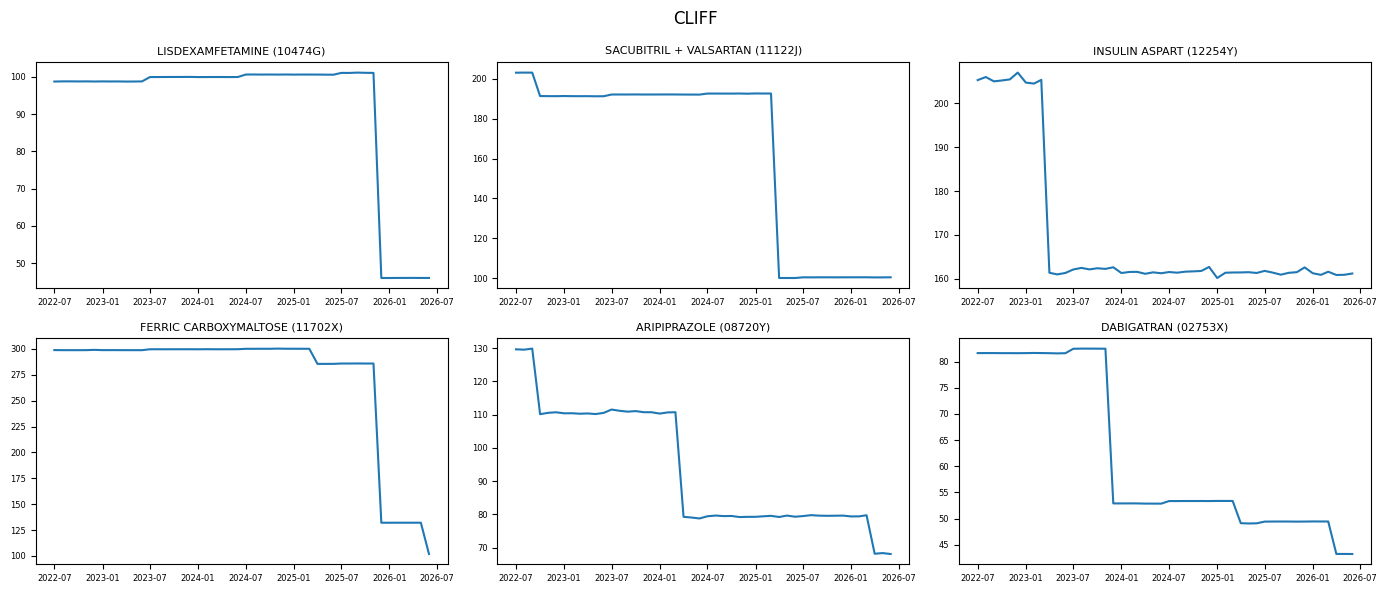

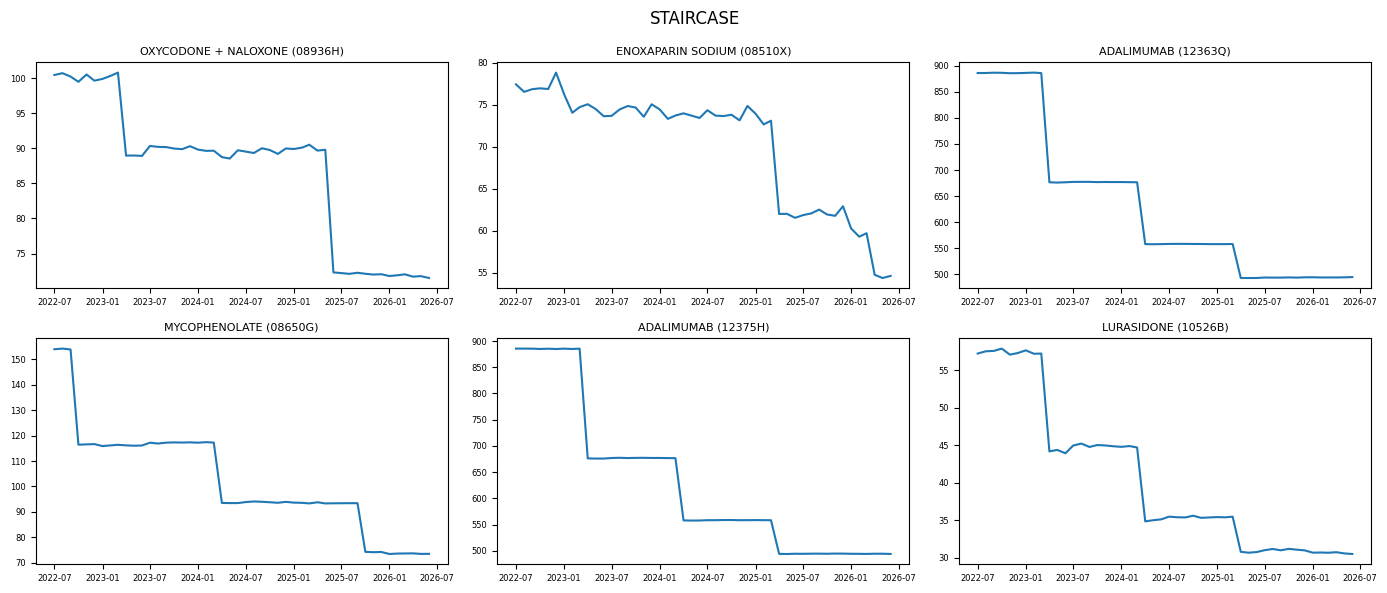

In [14]:
import numpy as np
rng = np.random.default_rng(42)

for label in ['cliff', 'staircase']:
    codes = diag[diag['pattern'] == label]['ITEM_CODE'].values
    picks = rng.choice(codes, 6, replace=False)
    fig, axes = plt.subplots(2, 3, figsize=(14, 6))
    for ax, code in zip(axes.flat, picks):
        d = monthly[monthly['ITEM_CODE'] == code].sort_values('date')
        ax.plot(d['date'], d['cost_per_script'])
        ax.set_title(f"{d['DRUG_NAME'].iloc[0]} ({code})", fontsize=8)
        ax.tick_params(labelsize=6)
    fig.suptitle(label.upper())
    plt.tight_layout()
    plt.show()

## Does volume respond to price?

Standard economics predicts that a large price fall increases quantity
demanded. Under the PBS this may not hold: the patient pays a fixed
co-payment regardless of what the medicine costs, so a fall in the listed
price is invisible at the counter, and the prescriber — not the buyer —
decides what is dispensed.

For each cliff item, the event month is taken as the month of the largest
single-month price drop. Average price and average monthly prescriptions
are compared across the 12 months before and the 12 months after.

Requiring a full 12 months either side reduces the sample from 60 items to
19. Most exclusions are events occurring in late 2025, which lack a
following year of data.

In [15]:
cliffs = diag[diag['pattern'] == 'cliff']['ITEM_CODE'].tolist()

rows = []
for code in cliffs:
    d = cand[cand['ITEM_CODE'] == code].sort_values('date').reset_index(drop=True)
    i = d['mom'].idxmin()                      # month of the largest drop
    if i < 12 or i > len(d) - 13:              # need 12 months either side
        continue
    pre  = d.iloc[i-12:i]
    post = d.iloc[i:i+12]
    rows.append({
        'ITEM_CODE': code,
        'event_date': d.loc[i, 'date'],
        'pre_price': pre['cost_per_script'].mean(),
        'post_price': post['cost_per_script'].mean(),
        'pre_scripts': pre['scripts'].mean(),
        'post_scripts': post['scripts'].mean(),
    })

ev = pd.DataFrame(rows)
ev['price_change'] = (ev['post_price'] - ev['pre_price']) / ev['pre_price'] * 100
ev['volume_change'] = (ev['post_scripts'] - ev['pre_scripts']) / ev['pre_scripts'] * 100

print(len(ev))
print(ev[['price_change', 'volume_change']].describe())

19
       price_change  volume_change
count     19.000000      19.000000
mean     -34.654015       1.480823
std       10.920428      18.549069
min      -47.804162     -47.585142
25%      -47.188551      -5.239115
50%      -34.154663       0.554111
75%      -25.068695      14.070376
max      -17.701457      25.782890


## Testing for a relationship

Across the 19 events, price fell by a mean of 34.7% (median 34.2%, range
17.7% to 47.8%) while mean volume change was +1.5% (median +0.6%).

The scatter shows no clear structure. The item-level correlation of −0.281
is in the direction economics predicts, but is not distinguishable from
zero (p = 0.244), and the 95% confidence interval for mean volume change
runs from −7.5% to +10.4% — spanning zero, and wide enough that a moderate
effect in either direction cannot be excluded.

               price_change  volume_change
price_change       1.000000      -0.280658
volume_change     -0.280658       1.000000


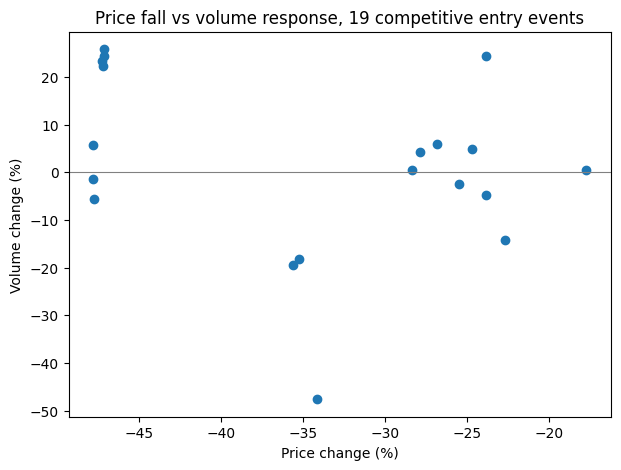

In [16]:
print(ev[['price_change', 'volume_change']].corr())

plt.figure(figsize=(7, 5))
plt.scatter(ev['price_change'], ev['volume_change'])
plt.axhline(0, color='grey', lw=0.8)
plt.xlabel('Price change (%)')
plt.ylabel('Volume change (%)')
plt.title('Price fall vs volume response, 19 competitive entry events')
plt.show()

## Sample independence

Inspecting the events by drug name reveals that the 19 items are only 8
distinct molecules: guanfacine (4 strengths), aripiprazole (4), apixaban
(3), sacubitril + valsartan (3), dabigatran (2), and palonosetron,
ticagrelor and enoxaparin sodium individually.

Different strengths of the same molecule share a single pricing event and a
single demand curve. They are not independent observations, so the
item-level tests above are computed on an inflated sample size and their
p-values are optimistic. The effective sample is 8, not 19.

The clustering is itself informative. Within each molecule the volume
response is highly consistent — all four guanfacine strengths move between
+22% and +26%, both dabigatran strengths between −18% and −19%, all four
aripiprazole strengths between +0.4% and +5.9%. Independent strengths
landing within a few percentage points of one another indicates a real,
drug-specific volume response rather than noise.

In [17]:
ev.merge(labels, on='ITEM_CODE')[['DRUG_NAME','FORM/STRENGTH','price_change','volume_change']].sort_values('price_change')

,DRUG_NAME,FORM/STRENGTH,price_change,volume_change
14,SACUBITRIL + VALSARTAN,Tablet containing sacubitril 48.6 mg with vals...,-47.804162,-1.453176
13,SACUBITRIL + VALSARTAN,Tablet containing sacubitril 24.3 mg with vals...,-47.799335,5.651199
12,SACUBITRIL + VALSARTAN,Tablet containing sacubitril 97.2 mg with vals...,-47.784794,-5.642871
16,GUANFACINE,Tablet 4 mg (as hydrochloride),-47.291031,23.328285
15,GUANFACINE,Tablet 3 mg (as hydrochloride),-47.218032,22.269499
18,GUANFACINE,Tablet 1 mg (as hydrochloride),-47.159070,24.435106
17,GUANFACINE,Tablet 2 mg (as hydrochloride),-47.152945,25.782890
4,DABIGATRAN,Capsule 150 mg (as mesilate),-35.610850,-19.366693
3,DABIGATRAN,Capsule 110 mg (as mesilate),-35.251529,-18.105184
6,PALONOSETRON,Injection 250 micrograms (as hydrochloride) in...,-34.154663,-47.585142


## Molecule-level analysis

Averaging strengths within each molecule gives 8 independent observations.

Mean volume change is not distinguishable from zero (t = −0.78, p = 0.46),
and price change and volume change are uncorrelated (r = −0.15, p = 0.72).
The correlation sign reverses from the item-level test, which supports
treating the earlier −0.281 as an artefact of pseudo-replication.

The individual molecules make the point more clearly than the statistics.
Guanfacine and sacubitril + valsartan both fell approximately 47%;
guanfacine's volume rose 24% while sacubitril's was unchanged. Dabigatran
fell 35% and volume fell 19% — the opposite of the predicted direction.

**Price does not explain volume. Drug-specific factors do.** Plausible
candidates — rising ADHD diagnosis rates for guanfacine, clinical
displacement by apixaban for dabigatran — cannot be tested with this
dataset and are offered as hypotheses only.

**Finding.** Across 8 molecules, a mean price fall of 32% produced no
detectable change in prescription volume. This is consistent with PBS
structure: the patient co-payment is fixed, so the price signal does not
reach the point of demand, and savings from generic competition accrue to
government rather than expanding access.

n = 8 is a small sample and these tests are underpowered. The finding is
reported as no detectable effect, not as evidence of no effect.

In [18]:
from scipy import stats
mol = (ev.merge(labels, on='ITEM_CODE')
         .groupby('DRUG_NAME')[['price_change','volume_change']].mean()
         .reset_index())
print(mol)
print(stats.ttest_1samp(mol['volume_change'], 0))
print(stats.pearsonr(mol['price_change'], mol['volume_change']))

                DRUG_NAME  price_change  volume_change
0                APIXABAN    -24.358426       5.692111
1            ARIPIPRAZOLE    -26.933933       3.861573
2              DABIGATRAN    -35.431189     -18.735939
3       ENOXAPARIN SODIUM    -17.701457       0.554111
4              GUANFACINE    -47.205269      23.953945
5            PALONOSETRON    -34.154663     -47.585142
6  SACUBITRIL + VALSARTAN    -47.796097      -0.481616
7              TICAGRELOR    -22.687399     -14.255003
TtestResult(statistic=np.float64(-0.7815125396830449), pvalue=np.float64(0.4601120352005371), df=np.int64(7))
PearsonRResult(statistic=np.float64(-0.15236962232862844), pvalue=np.float64(0.7186980220990326))


In [19]:
summary = (ev.merge(labels, on='ITEM_CODE')
             .merge(diag[['ITEM_CODE','share_of_decline','n_drops_5pct']], on='ITEM_CODE'))

summary = summary[['DRUG_NAME','FORM/STRENGTH','ITEM_CODE','event_date',
                   'pre_price','post_price','price_change',
                   'pre_scripts','post_scripts','volume_change',
                   'share_of_decline']]

summary = summary.sort_values(['DRUG_NAME','FORM/STRENGTH']).round(2)
print(summary.shape)
summary

(19, 11)


,DRUG_NAME,FORM/STRENGTH,ITEM_CODE,event_date,pre_price,post_price,price_change,pre_scripts,post_scripts,volume_change,share_of_decline
2,APIXABAN,Tablet 2.5 mg,02744K,2024-08-01,90.70,69.09,-23.82,90877.42,86483.17,-4.84,0.93
5,APIXABAN,Tablet 2.5 mg,05061J,2024-08-01,90.36,68.85,-23.80,4753.67,5908.92,24.30,0.93
1,APIXABAN,Tablet 5 mg,02735Y,2024-08-01,90.67,67.59,-25.45,234097.33,228501.00,-2.39,0.93
8,ARIPIPRAZOLE,Tablet 10 mg,08717T,2024-04-01,58.68,44.19,-24.68,12211.17,12809.92,4.90,0.77
9,ARIPIPRAZOLE,Tablet 15 mg,08718W,2024-04-01,78.54,57.47,-26.82,4769.00,5049.00,5.87,0.75
10,ARIPIPRAZOLE,Tablet 20 mg,08719X,2024-04-01,93.44,67.41,-27.86,4800.67,5003.75,4.23,0.76
11,ARIPIPRAZOLE,Tablet 30 mg,08720Y,2024-04-01,110.72,79.30,-28.37,3360.33,3375.17,0.44,0.74
3,DABIGATRAN,Capsule 110 mg (as mesilate),02753X,2023-12-01,81.97,53.08,-35.25,23379.58,19146.67,-18.11,0.83
4,DABIGATRAN,Capsule 150 mg (as mesilate),02769R,2023-12-01,81.95,52.77,-35.61,15987.50,12891.25,-19.37,0.83
7,ENOXAPARIN SODIUM,Injection containing enoxaparin sodium 40 mg (...,08639Q,2025-04-01,83.40,68.64,-17.70,2947.67,2964.00,0.55,0.76


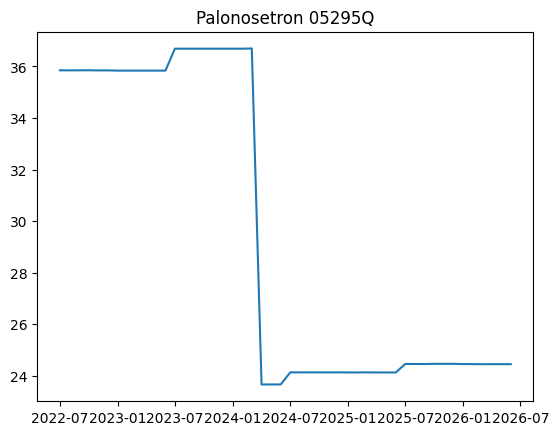

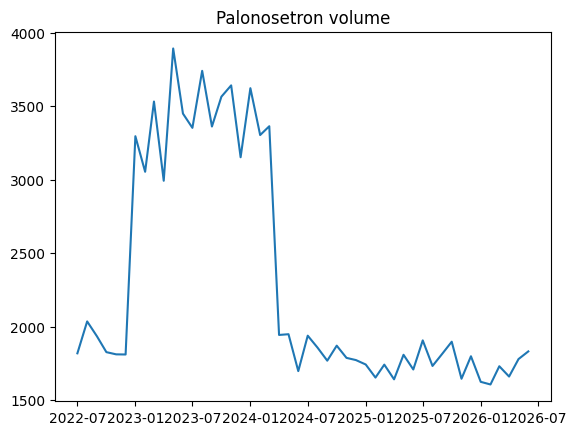

In [20]:
summary[summary['DRUG_NAME'].isin(['APIXABAN','PALONOSETRON'])][['DRUG_NAME','FORM/STRENGTH','ITEM_CODE','pre_scripts','volume_change']]

d = monthly[monthly['ITEM_CODE']=='05295Q'].sort_values('date')
plt.plot(d['date'], d['cost_per_script']); plt.title('Palonosetron 05295Q'); plt.show()
plt.plot(d['date'], d['scripts']); plt.title('Palonosetron volume'); plt.show()

In [21]:
mol_x = mol[mol['DRUG_NAME'] != 'PALONOSETRON']
print(mol_x[['DRUG_NAME','price_change','volume_change']])
print(stats.ttest_1samp(mol_x['volume_change'], 0))
print(stats.pearsonr(mol_x['price_change'], mol_x['volume_change']))

                DRUG_NAME  price_change  volume_change
0                APIXABAN    -24.358426       5.692111
1            ARIPIPRAZOLE    -26.933933       3.861573
2              DABIGATRAN    -35.431189     -18.735939
3       ENOXAPARIN SODIUM    -17.701457       0.554111
4              GUANFACINE    -47.205269      23.953945
6  SACUBITRIL + VALSARTAN    -47.796097      -0.481616
7              TICAGRELOR    -22.687399     -14.255003
TtestResult(statistic=np.float64(0.015907529929760727), pvalue=np.float64(0.9878239330461924), df=np.int64(6))
PearsonRResult(statistic=np.float64(-0.350820852822295), pvalue=np.float64(0.4403912174672118))


## Summary tables and sensitivity check

Two outputs: one row per item-level event (19 rows) and a molecule-level
rollup (8 rows), both exported to CSV for the dashboard.

Event dates cluster within molecules exactly as expected — all four
guanfacine strengths on 2023-10-01, all three sacubitril + valsartan
strengths on 2025-04-01, both dabigatran strengths on 2023-12-01. These
dates fall on 1 April, 1 October and 1 December, which are PBS
price-change dates. This supports the reading that the mechanism is a
regulated price reduction triggered by competitive entry.

**Palonosetron excluded from the primary test.** Plotting it separately
shows volume stepping up from roughly 1,800 to 3,500 scripts per month
through 2023, then returning to about 1,800 in early 2024 — up and back to
baseline, which is not a demand response to price. The price drop coincides
with that return, so the event window records a −48% volume change that is
almost certainly a supply or listing effect rather than a price effect. As
a single-item molecule it carried a full one-eighth weight and the largest
volume move in the dataset.

The finding is unchanged either way. Mean volume change is indistinguishable
from zero both with palonosetron (t = −0.78, p = 0.46, n = 8) and without it
(t = 0.02, p = 0.99, n = 7). The price–volume correlation is
non-significant in both cases (r = −0.15 and r = −0.35 respectively).

**Caveat on weighting.** The molecule-level average weights each drug
equally, so apixaban at roughly 330,000 scripts per month counts the same as
enoxaparin at roughly 2,900. This answers "what happens to a typical drug"
rather than "what happens to the market". A volume-weighted analysis would
be a reasonable extension and might give a different picture.

In [22]:
mol_summary = (summary.groupby('DRUG_NAME')
                      .agg(strengths=('ITEM_CODE','nunique'),
                           event_date=('event_date','min'),
                           mean_price_change=('price_change','mean'),
                           mean_volume_change=('volume_change','mean'),
                           pre_scripts=('pre_scripts','sum'),
                           post_scripts=('post_scripts','sum'))
                      .round(2).reset_index()
                      .sort_values('mean_price_change'))

mol_summary

,DRUG_NAME,strengths,event_date,mean_price_change,mean_volume_change,pre_scripts,post_scripts
6,SACUBITRIL + VALSARTAN,3,2025-04-01,-47.79,-0.48,61491.00,61941.00
4,GUANFACINE,4,2023-10-01,-47.20,23.96,36688.00,45564.00
2,DABIGATRAN,2,2023-12-01,-35.43,-18.74,39367.08,32037.92
5,PALONOSETRON,1,2024-04-01,-34.15,-47.59,3452.58,1809.67
1,ARIPIPRAZOLE,4,2024-04-01,-26.93,3.86,25141.17,26237.84
0,APIXABAN,3,2024-08-01,-24.36,5.69,329728.42,320893.09
7,TICAGRELOR,1,2025-02-01,-22.69,-14.26,14769.08,12663.75
3,ENOXAPARIN SODIUM,1,2025-04-01,-17.70,0.55,2947.67,2964.00


In [23]:
summary.to_csv('/content/drive/MyDrive/pbs-data/event_summary.csv', index=False)
mol_summary.to_csv('/content/drive/MyDrive/pbs-data/molecule_summary.csv', index=False)
monthly[monthly['ITEM_CODE'].isin(ev['ITEM_CODE'])].to_csv('/content/drive/MyDrive/pbs-data/monthly_series.csv', index=False)

## SQL implementation

The pipeline is reimplemented in SQL against a SQLite database built from
the same filtered dataset.

Two reasons. First, as an independent check: each query should reproduce
the row counts and figures already obtained in pandas, and a mismatch would
indicate an error in one implementation or the other. Second, production
analytics work is typically SQL-first, with data queried from a warehouse
rather than loaded wholesale into memory.

Queries are also saved separately in `sql/queries.sql`.

In [24]:
import sqlite3

conn = sqlite3.connect('/content/pbs.db')
work.to_sql('dispensing', conn, if_exists='replace', index=False)
drug_map.to_sql('drug_map', conn, if_exists='replace', index=False)

print(pd.read_sql("SELECT COUNT(*) AS n FROM dispensing", conn))
print(pd.read_sql("SELECT COUNT(*) AS n FROM drug_map", conn))

        n
0  789577
       n
0  12162


### Monthly aggregation

The SQL equivalent of the pandas `monthly` table: `GROUP BY` collapses
rows the same way `.groupby()` does, and the `LEFT JOIN` onto the item-code
map corresponds to `.merge(how='left')`.

Returns 195,389 rows, matching the pandas result exactly, with identical
cost per script values at the row level.

Note that `"FORM/STRENGTH"` requires double quotes — the slash would
otherwise be parsed as division.

In [25]:
q_monthly = """
SELECT
    d.ITEM_CODE,
    d.date,
    SUM(d.PRESCRIPTIONS) AS scripts,
    SUM(d.TOTAL_COST)    AS cost,
    SUM(d.TOTAL_COST) / SUM(d.PRESCRIPTIONS) AS cost_per_script,
    m.DRUG_NAME,
    m."FORM/STRENGTH" AS form_strength
FROM dispensing d
LEFT JOIN drug_map m ON d.ITEM_CODE = m.ITEM_CODE
GROUP BY d.ITEM_CODE, d.date
"""

sql_monthly = pd.read_sql(q_monthly, conn)
print(sql_monthly.shape)
sql_monthly.head()

(195389, 7)


,ITEM_CODE,date,scripts,cost,cost_per_script,DRUG_NAME,form_strength
0,00000B,2022-07-01 00:00:00,1747,79710.93,45.627321,None,None
1,00000B,2022-08-01 00:00:00,1910,117560.95,61.550236,None,None
2,00000B,2022-09-01 00:00:00,1730,86583.38,50.048197,None,None
3,00000B,2022-10-01 00:00:00,1714,97024.92,56.607305,None,None
4,00000B,2022-11-01 00:00:00,1721,119127.70,69.220046,None,None


### Candidate selection

Applies the same two filters as before: present in all 48 months, and more
than 100,000 total prescriptions. Returns 885 items, matching pandas.

This uses `HAVING` rather than `WHERE`. `WHERE` filters individual rows
before grouping; `HAVING` filters groups after aggregation, which is
necessary here because the count of months does not exist until the rows
have been grouped.

In [26]:
q_candidates = """
SELECT
    ITEM_CODE,
    COUNT(DISTINCT date) AS months,
    SUM(scripts)         AS total_scripts
FROM (
    SELECT ITEM_CODE, date, SUM(PRESCRIPTIONS) AS scripts
    FROM dispensing
    GROUP BY ITEM_CODE, date
)
GROUP BY ITEM_CODE
HAVING COUNT(DISTINCT date) = 48
   AND SUM(scripts) > 100000
"""

sql_candidates = pd.read_sql(q_candidates, conn)
print(len(sql_candidates))

885


### Month-on-month price change

Three chained CTEs — monthly aggregation, candidate filter, then a window
function computing each month's change against the previous month.

`LAG(cost_per_script) OVER (PARTITION BY ITEM_CODE ORDER BY date)` returns
the prior month's price for the same item. `PARTITION BY` restarts the
comparison at each item so prices are never compared across different
drugs; `ORDER BY` defines the sequence. This is the direct equivalent of
the pandas `groupby().pct_change()` used earlier.

This query is more informative than the pandas approach it replaces. The
earlier method compared the first six months against the last six and
required a separate step to locate the event month; this returns the exact
month of every drop directly.

The output confirms the earlier findings from an independent
implementation: ustekinumab at −79.8% in August 2025, and all six
lisdexamfetamine item codes at −54.4% on 1 December 2025 — matching the
externally verified PBS price change date.

Two items appear here that did not reach the volume analysis — 08644Y
(−58.2%, February 2023) and the aflibercept codes (−65%, February 2026) —
because their event dates fall too close to the edges of the window to
allow a full 12 months either side.

In [27]:
q_change = """
WITH monthly AS (
    SELECT
        ITEM_CODE,
        date,
        SUM(PRESCRIPTIONS) AS scripts,
        SUM(TOTAL_COST) / SUM(PRESCRIPTIONS) AS cost_per_script
    FROM dispensing
    GROUP BY ITEM_CODE, date
),
candidates AS (
    SELECT ITEM_CODE
    FROM monthly
    GROUP BY ITEM_CODE
    HAVING COUNT(DISTINCT date) = 48 AND SUM(scripts) > 100000
),
with_lag AS (
    SELECT
        m.ITEM_CODE,
        m.date,
        m.cost_per_script,
        LAG(m.cost_per_script) OVER (PARTITION BY m.ITEM_CODE ORDER BY m.date) AS prev_price
    FROM monthly m
    JOIN candidates c ON m.ITEM_CODE = c.ITEM_CODE
)
SELECT
    ITEM_CODE,
    date,
    cost_per_script,
    prev_price,
    (cost_per_script - prev_price) / prev_price * 100 AS pct_change
FROM with_lag
WHERE prev_price IS NOT NULL
ORDER BY pct_change
LIMIT 15
"""

pd.read_sql(q_change, conn)

,ITEM_CODE,date,cost_per_script,prev_price,pct_change
0,11178H,2025-08-01 00:00:00,1571.576298,7778.543768,-79.796009
1,12153P,2026-02-01 00:00:00,383.429636,1094.985770,-64.983140
2,12152N,2026-02-01 00:00:00,346.762099,974.283730,-64.408510
3,08644Y,2023-02-01 00:00:00,31.188061,74.673694,-58.234206
4,11884L,2025-12-01 00:00:00,46.083756,101.174865,-54.451379
5,10486X,2025-12-01 00:00:00,46.042103,101.081109,-54.450339
6,11898F,2025-12-01 00:00:00,46.028640,101.044126,-54.446991
7,10492F,2025-12-01 00:00:00,46.045750,101.053248,-54.434171
8,10474G,2025-12-01 00:00:00,46.035440,101.027959,-54.432970
9,11897E,2025-12-01 00:00:00,46.063910,101.036842,-54.408799


### Identifying event months

`ROW_NUMBER() OVER (PARTITION BY ITEM_CODE ORDER BY pct_change)` ranks each
item's monthly changes from steepest fall upward, so rank 1 is that item's
largest single-month drop. Filtering to `rn = 1` returns one event per item.

The event dates match the pandas results exactly — guanfacine on
2023-10-01, dabigatran on 2023-12-01, sacubitril + valsartan on 2025-04-01.

In [28]:
q_event = """
WITH monthly AS (
    SELECT ITEM_CODE, date,
           SUM(PRESCRIPTIONS) AS scripts,
           SUM(TOTAL_COST) / SUM(PRESCRIPTIONS) AS cost_per_script
    FROM dispensing
    GROUP BY ITEM_CODE, date
),
candidates AS (
    SELECT ITEM_CODE FROM monthly
    GROUP BY ITEM_CODE
    HAVING COUNT(DISTINCT date) = 48 AND SUM(scripts) > 100000
),
changes AS (
    SELECT m.ITEM_CODE, m.date, m.scripts, m.cost_per_script,
           (m.cost_per_script - LAG(m.cost_per_script)
                OVER (PARTITION BY m.ITEM_CODE ORDER BY m.date))
           / LAG(m.cost_per_script)
                OVER (PARTITION BY m.ITEM_CODE ORDER BY m.date) * 100 AS pct_change
    FROM monthly m
    JOIN candidates c ON m.ITEM_CODE = c.ITEM_CODE
),
events AS (
    SELECT ITEM_CODE, date AS event_date, pct_change,
           ROW_NUMBER() OVER (PARTITION BY ITEM_CODE ORDER BY pct_change) AS rn
    FROM changes
    WHERE pct_change IS NOT NULL
)
SELECT ITEM_CODE, event_date, pct_change AS event_drop
FROM events
WHERE rn = 1 AND pct_change < -15
ORDER BY pct_change
LIMIT 20
"""

pd.read_sql(q_event, conn)

,ITEM_CODE,event_date,event_drop
0,11178H,2025-08-01 00:00:00,-79.796009
1,12153P,2026-02-01 00:00:00,-64.983140
2,12152N,2026-02-01 00:00:00,-64.408510
3,08644Y,2023-02-01 00:00:00,-58.234206
4,11884L,2025-12-01 00:00:00,-54.451379
5,10486X,2025-12-01 00:00:00,-54.450339
6,11898F,2025-12-01 00:00:00,-54.446991
7,10492F,2025-12-01 00:00:00,-54.434171
8,10474G,2025-12-01 00:00:00,-54.432970
9,11897E,2025-12-01 00:00:00,-54.408799


### Pre/post event windows

`AVG(CASE WHEN ... THEN ... END)` computes four different windows in a single
pass — average price and average volume, before and after the event month.
Rows failing each condition evaluate to NULL and are ignored by AVG.

`HAVING COUNT(*) = 24` enforces a full 12 months either side of the event,
the SQL equivalent of the index check used in the pandas implementation.

**The two implementations return different row counts, by design.** SQL
returns 30 items, pandas returned 19. The event definitions differ: the
pandas pipeline required a 20% decline measured from the first six months
to the last six, plus a share_of_decline of at least 0.7, whereas this query
requires only a single monthly drop exceeding 15%.

The eleven additional items — carvedilol, letrozole, levodopa + benserazide,
lurasidone, oxycodone + naloxone, tacrolimus and others — are smaller
single-month reductions that the pandas classification excluded as not
meeting the four-year decline threshold.

Where the two implementations do overlap, the figures agree exactly. For
example apixaban 02735Y returns pre_price 90.665 and post_price 67.588 in
both, and all four guanfacine strengths match to six decimal places. The
looser SQL definition is retained deliberately: it demonstrates how
sensitive the event count is to the threshold chosen, which is worth
recording rather than concealing.

One row, item 00013Q "EXTEMPORANEOUSLY PREPARED", is a placeholder category
rather than a specific medicine and would be excluded from any downstream
analysis.

In [29]:
q_prepost = """
WITH monthly AS (
    SELECT ITEM_CODE, date,
           SUM(PRESCRIPTIONS) AS scripts,
           SUM(TOTAL_COST) / SUM(PRESCRIPTIONS) AS cost_per_script
    FROM dispensing
    GROUP BY ITEM_CODE, date
),
candidates AS (
    SELECT ITEM_CODE FROM monthly
    GROUP BY ITEM_CODE
    HAVING COUNT(DISTINCT date) = 48 AND SUM(scripts) > 100000
),
changes AS (
    SELECT m.ITEM_CODE, m.date,
           (m.cost_per_script - LAG(m.cost_per_script)
                OVER (PARTITION BY m.ITEM_CODE ORDER BY m.date))
           / LAG(m.cost_per_script)
                OVER (PARTITION BY m.ITEM_CODE ORDER BY m.date) * 100 AS pct_change
    FROM monthly m
    JOIN candidates c ON m.ITEM_CODE = c.ITEM_CODE
),
events AS (
    SELECT ITEM_CODE, date AS event_date,
           ROW_NUMBER() OVER (PARTITION BY ITEM_CODE ORDER BY pct_change) AS rn
    FROM changes
    WHERE pct_change IS NOT NULL AND pct_change < -15
)
SELECT
    e.ITEM_CODE,
    dm.DRUG_NAME,
    e.event_date,
    AVG(CASE WHEN m.date <  e.event_date THEN m.cost_per_script END) AS pre_price,
    AVG(CASE WHEN m.date >= e.event_date THEN m.cost_per_script END) AS post_price,
    AVG(CASE WHEN m.date <  e.event_date THEN m.scripts END)         AS pre_scripts,
    AVG(CASE WHEN m.date >= e.event_date THEN m.scripts END)         AS post_scripts
FROM events e
JOIN monthly m
  ON m.ITEM_CODE = e.ITEM_CODE
 AND m.date >= DATE(e.event_date, '-12 months')
 AND m.date <  DATE(e.event_date, '+12 months')
LEFT JOIN drug_map dm ON dm.ITEM_CODE = e.ITEM_CODE
WHERE e.rn = 1
GROUP BY e.ITEM_CODE, dm.DRUG_NAME, e.event_date
HAVING COUNT(*) = 24
ORDER BY dm.DRUG_NAME
"""

pd.read_sql(q_prepost, conn)

,ITEM_CODE,DRUG_NAME,event_date,pre_price,post_price,pre_scripts,post_scripts
0,02735Y,APIXABAN,2024-08-01 00:00:00,90.665367,67.587544,234097.333333,228501.000000
1,02744K,APIXABAN,2024-08-01 00:00:00,90.697406,69.092935,90877.416667,86483.166667
2,05061J,APIXABAN,2024-08-01 00:00:00,90.355713,68.850106,4753.666667,5908.916667
3,08717T,ARIPIPRAZOLE,2024-04-01 00:00:00,58.677008,44.193442,12211.166667,12809.916667
4,08718W,ARIPIPRAZOLE,2024-04-01 00:00:00,78.538531,57.474174,4769.000000,5049.000000
5,08719X,ARIPIPRAZOLE,2024-04-01 00:00:00,93.436347,67.407372,4800.666667,5003.750000
6,08720Y,ARIPIPRAZOLE,2024-04-01 00:00:00,110.720564,79.304337,3360.333333,3375.166667
7,08258P,CARVEDILOL,2023-10-01 00:00:00,23.424042,20.265657,8605.833333,7053.166667
8,02753X,DABIGATRAN,2023-12-01 00:00:00,81.972008,53.075622,23379.583333,19146.666667
9,02769R,DABIGATRAN,2023-12-01 00:00:00,81.954394,52.769738,15987.500000,12891.250000
